In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 130,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.facecolor': '#fafaf8',
    'axes.facecolor': '#fafaf8',
})

In [3]:
# ─── Shared Data ─────────────────────────────────────────────────────────────
SYSTEMS = ['SAE LogReg', 'SAE MLP', 'SAE RF', 'Cluster', 'Confidence', 'Random']
COLORS  = ['#1d4ed8', '#16a34a', '#c2410c', '#7e22ce', '#b91c1c', '#9ca3af']
CONFIGS = ['1B-L7', '1B-L17', '1B-L22', '4B-L9', '4B-L17', '4B-L29']
COVERAGES = [20, 30, 40]

AUROC = {
    'SAE LogReg': [0.6179, 0.8289, 0.7544,  0.4864, 0.7113, 0.7534],
    'SAE MLP':    [0.5639, 0.8146, 0.7108,  0.4382, 0.7276, 0.8087],
    'SAE RF':     [0.6782, 0.7811, 0.7344,  0.5795, 0.8019, 0.7756],
    'Cluster':    [0.4759, 0.6570, 0.5939,  0.5277, 0.6358, 0.6364],
    'Confidence': [0.4792, 0.4792, 0.4792,  0.5915, 0.5915, 0.5915],
    'Random':     [0.4097, 0.4097, 0.4097,  0.4946, 0.4946, 0.4946],
}
F1_30 = {
    'SAE LogReg': [0.5000, 0.6190, 0.5952,  0.2581, 0.4839, 0.5806],
    'SAE MLP':    [0.4048, 0.5952, 0.5000,  0.2258, 0.4839, 0.6129],
    'SAE RF':     [0.5714, 0.5952, 0.5714,  0.2903, 0.6452, 0.5484],
    'Cluster':    [0.4009, 0.5060, 0.4145,  0.3486, 0.3742, 0.4065],
    'Confidence': [0.4000, 0.4000, 0.4000,  0.3548, 0.3548, 0.3548],
    'Random':     [0.3333, 0.3333, 0.3333,  0.3226, 0.3226, 0.3226],
}

# [20%, 30%, 40%] per config per system
PRECK = {
    '1B-L7':  {'SAE LogReg':[0.65,0.70,0.675],'SAE MLP':[0.40,0.567,0.60],'SAE RF':[0.80,0.80,0.70],
               'Cluster':[0.49,0.52,0.50],'Confidence':[0.55,0.533,0.55],'Random':[0.45,0.467,0.45]},
    '1B-L17': {'SAE LogReg':[0.80,0.867,0.825],'SAE MLP':[0.85,0.833,0.80],'SAE RF':[0.80,0.833,0.85],
               'Cluster':[0.69,0.70,0.68],'Confidence':[0.55,0.533,0.55],'Random':[0.45,0.467,0.45]},
    '1B-L22': {'SAE LogReg':[0.90,0.833,0.80],'SAE MLP':[0.75,0.70,0.725],'SAE RF':[0.75,0.80,0.775],
               'Cluster':[0.58,0.573,0.605],'Confidence':[0.55,0.533,0.55],'Random':[0.45,0.467,0.45]},
    '4B-L9':  {'SAE LogReg':[0.30,0.267,0.30],'SAE MLP':[0.20,0.233,0.25],'SAE RF':[0.30,0.30,0.425],
               'Cluster':[0.37,0.353,0.355],'Confidence':[0.35,0.367,0.35],'Random':[0.45,0.333,0.30]},
    '4B-L17': {'SAE LogReg':[0.60,0.50,0.475],'SAE MLP':[0.50,0.50,0.55],'SAE RF':[0.70,0.667,0.60],
               'Cluster':[0.40,0.387,0.405],'Confidence':[0.35,0.367,0.35],'Random':[0.45,0.333,0.30]},
    '4B-L29': {'SAE LogReg':[0.65,0.60,0.50],'SAE MLP':[0.70,0.633,0.60],'SAE RF':[0.60,0.567,0.60],
               'Cluster':[0.42,0.42,0.415],'Confidence':[0.35,0.367,0.35],'Random':[0.45,0.333,0.30]},
}
ACCREM = {
    '1B-L7':  {'SAE LogReg':[0.500,0.542,0.565],'SAE MLP':[0.439,0.486,0.516],'SAE RF':[0.537,0.583,0.581],
               'Cluster':[0.460,0.466,0.450],'Confidence':[0.476,0.472,0.484],'Random':[0.451,0.444,0.419]},
    '1B-L17': {'SAE LogReg':[0.537,0.611,0.661],'SAE MLP':[0.549,0.597,0.645],'SAE RF':[0.537,0.597,0.677],
               'Cluster':[0.510,0.543,0.570],'Confidence':[0.476,0.472,0.484],'Random':[0.451,0.444,0.419]},
    '1B-L22': {'SAE LogReg':[0.561,0.597,0.645],'SAE MLP':[0.524,0.542,0.597],'SAE RF':[0.524,0.583,0.629],
               'Cluster':[0.483,0.489,0.520],'Confidence':[0.476,0.472,0.484],'Random':[0.451,0.444,0.419]},
    '4B-L9':  {'SAE LogReg':[0.679,0.662,0.672],'SAE MLP':[0.654,0.648,0.639],'SAE RF':[0.679,0.676,0.754],
               'Cluster':[0.693,0.694,0.703],'Confidence':[0.691,0.704,0.705],'Random':[0.716,0.690,0.672]},
    '4B-L17': {'SAE LogReg':[0.753,0.761,0.787],'SAE MLP':[0.728,0.761,0.836],'SAE RF':[0.778,0.831,0.869],
               'Cluster':[0.700,0.709,0.737],'Confidence':[0.691,0.704,0.705],'Random':[0.716,0.690,0.672]},
    '4B-L29': {'SAE LogReg':[0.765,0.803,0.803],'SAE MLP':[0.778,0.817,0.869],'SAE RF':[0.753,0.789,0.869],
               'Cluster':[0.705,0.723,0.743],'Confidence':[0.691,0.704,0.705],'Random':[0.716,0.690,0.672]},
}

# Cluster profiles
HM1B = {
    'L7': [
        {'label':'C0 (n=36)',  'feats':[(1559,20.02),(16249,12.20),(750,10.92),(500,9.83),(895,8.13)]},
        {'label':'C1 (n=134)', 'feats':[(500,7.12),(16249,3.26),(477,2.39),(895,1.17),(1219,0.99)]},
        {'label':'C2 (n=95)',  'feats':[(204,7.51),(176,4.65),(62,4.42),(936,3.33),(648,3.06)]},
    ],
    'L17': [
        {'label':'C0 (n=83)',  'feats':[(3529,27.71),(1136,25.49),(1527,21.92),(4556,20.34),(259,19.73)]},
        {'label':'C1 (n=113)', 'feats':[(2083,48.63),(260,43.71),(891,34.25),(493,32.44),(8557,32.35)]},
        {'label':'C2 (n=69)',  'feats':[(137,53.87),(1136,49.45),(3529,47.78),(591,37.87),(898,35.91)]},
    ],
    'L22': [
        {'label':'C0 (n=84)',  'feats':[(187,108.63),(1095,86.78),(931,76.01),(1250,62.07),(2774,60.33)]},
        {'label':'C1 (n=84)',  'feats':[(2303,82.43),(2158,74.84),(679,60.30),(543,45.63),(1007,41.47)]},
        {'label':'C2 (n=97)',  'feats':[(367,87.40),(1307,47.86),(562,36.81),(13905,35.27),(14293,34.68)]},
    ],
}
HM4B = {
    'L9': [
        {'label':'C0 (n=52)', 'feats':[(6218,5.12),(13272,3.06),(15680,1.43),(449,1.24),(887,0.94)]},
        {'label':'C1 (n=46)', 'feats':[(1801,20.87),(759,7.86),(314,6.49),(323,6.38),(142,6.36)]},
        {'label':'C2 (n=62)', 'feats':[(4647,12.48),(6218,8.84),(654,5.35),(205,5.35),(312,4.26)]},
    ],
    'L17': [
        {'label':'C0 (n=66)', 'feats':[(3947,61.57),(4919,56.34),(1617,43.96),(2813,41.16),(7092,36.90)]},
        {'label':'C1 (n=78)', 'feats':[(6568,55.18),(9957,36.83),(3947,33.63),(15437,29.79),(5703,28.02)]},
        {'label':'C2 (n=16)', 'feats':[(7092,136.37),(3775,131.07),(496,100.03),(133,68.68),(225,60.56)]},
    ],
    'L29': [
        {'label':'C0 (n=65)', 'feats':[(1685,255.33),(12332,204.48),(165,202.35),(15345,177.36),(7525,171.72)]},
        {'label':'C1 (n=32)', 'feats':[(7525,530.73),(4609,345.14),(1128,287.55),(249,284.24),(15721,258.80)]},
        {'label':'C2 (n=63)', 'feats':[(8363,538.36),(9126,523.53),(165,269.16),(12160,268.03),(5679,264.88)]},
    ],
}

print('Data loaded.')

Data loaded.


## Plot 1 — AUROC Bar Chart (grouped by model)

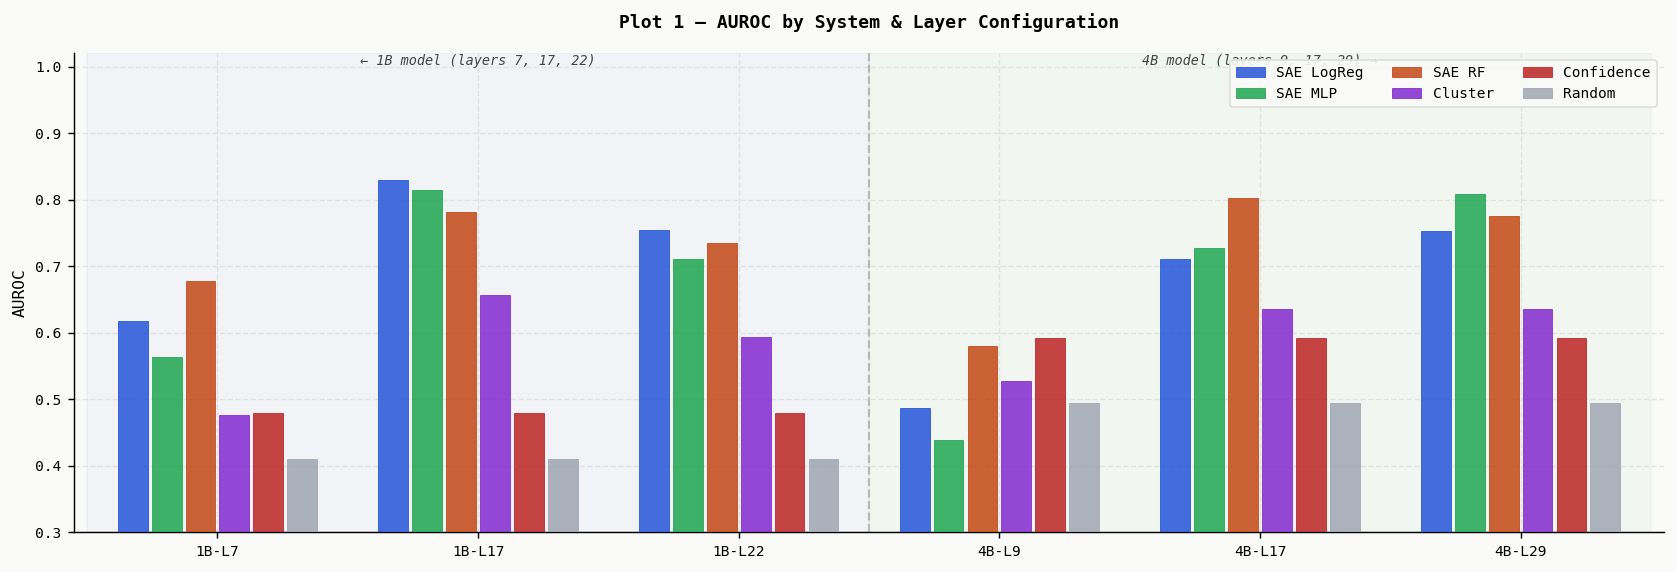

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))

n_sys = len(SYSTEMS)
n_cfg = len(CONFIGS)
x = np.arange(n_cfg)
total_w = 0.78
bw = total_w / n_sys
offsets = np.linspace(-total_w/2 + bw/2, total_w/2 - bw/2, n_sys)

for i, (sys, col) in enumerate(zip(SYSTEMS, COLORS)):
    bars = ax.bar(x + offsets[i], AUROC[sys], width=bw*0.88,
                  color=col, alpha=0.82, label=sys,
                  edgecolor=col, linewidth=0.5, zorder=3)

# Model group shading
ax.axvspan(-0.5, 2.5, color='#1d4ed8', alpha=0.04, zorder=0)
ax.axvspan(2.5, 5.5, color='#16a34a', alpha=0.04, zorder=0)
ax.axvline(2.5, color='#999', lw=1.2, ls='--', zorder=2, alpha=0.6)
ax.text(1.0, 0.975, '← 1B model (layers 7, 17, 22)',
        transform=ax.get_xaxis_transform(), ha='center', fontsize=7.5,
        color='#444', style='italic')
ax.text(4.0, 0.975, '4B model (layers 9, 17, 29) →',
        transform=ax.get_xaxis_transform(), ha='center', fontsize=7.5,
        color='#444', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(CONFIGS)
ax.set_ylabel('AUROC')
ax.set_ylim(0.30, 1.02)
ax.set_title('Plot 1 — AUROC by System & Layer Configuration', fontweight='bold', pad=14)
ax.legend(loc='upper right', ncol=3, framealpha=0.9, edgecolor='#ddd')
ax.set_xlim(-0.55, 5.55)
plt.tight_layout()
plt.show()

## Plot 2 — F1@30% Bar Chart (grouped by model)

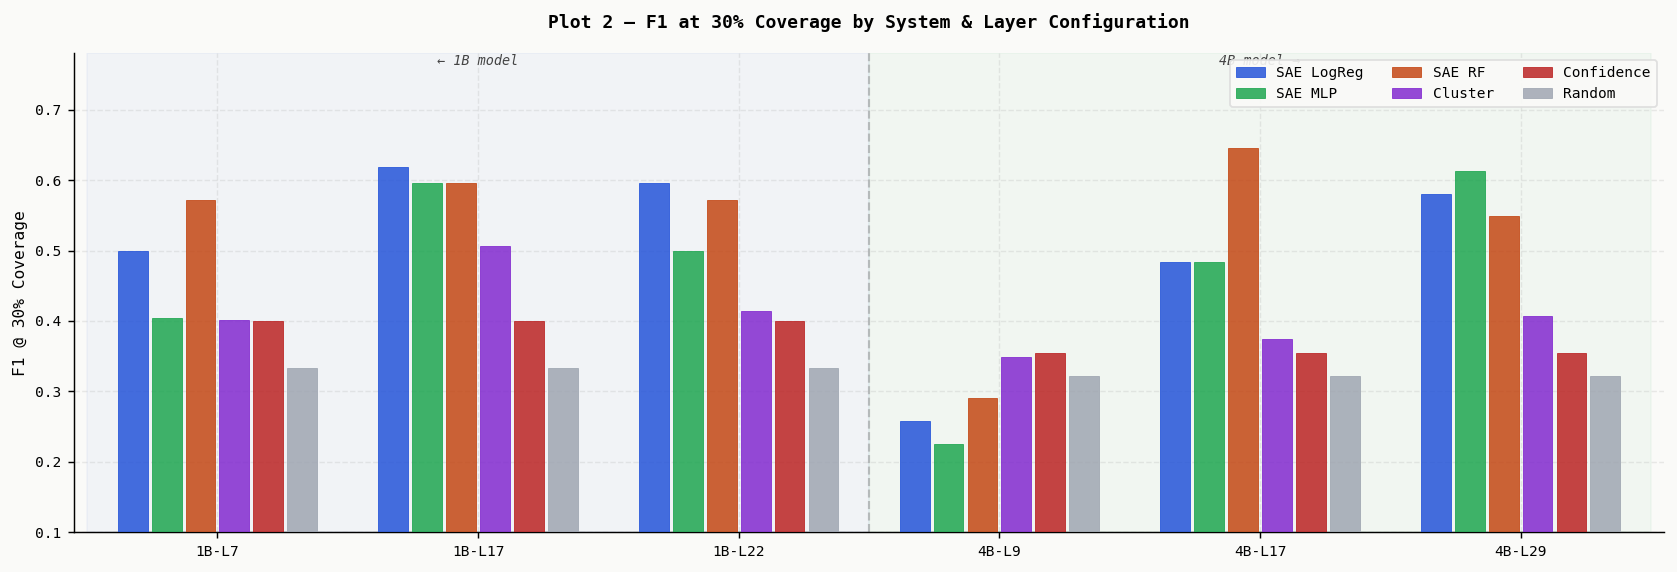

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))

for i, (sys, col) in enumerate(zip(SYSTEMS, COLORS)):
    ax.bar(x + offsets[i], F1_30[sys], width=bw*0.88,
           color=col, alpha=0.82, label=sys,
           edgecolor=col, linewidth=0.5, zorder=3)

ax.axvspan(-0.5, 2.5, color='#1d4ed8', alpha=0.04, zorder=0)
ax.axvspan(2.5, 5.5, color='#16a34a', alpha=0.04, zorder=0)
ax.axvline(2.5, color='#999', lw=1.2, ls='--', zorder=2, alpha=0.6)
ax.text(1.0, 0.975, '← 1B model', transform=ax.get_xaxis_transform(),
        ha='center', fontsize=7.5, color='#444', style='italic')
ax.text(4.0, 0.975, '4B model →', transform=ax.get_xaxis_transform(),
        ha='center', fontsize=7.5, color='#444', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(CONFIGS)
ax.set_ylabel('F1 @ 30% Coverage')
ax.set_ylim(0.10, 0.78)
ax.set_title('Plot 2 — F1 at 30% Coverage by System & Layer Configuration', fontweight='bold', pad=14)
ax.legend(loc='upper right', ncol=3, framealpha=0.9, edgecolor='#ddd')
ax.set_xlim(-0.55, 5.55)
plt.tight_layout()
plt.show()

## Plot 3 — Prec@k Line Charts

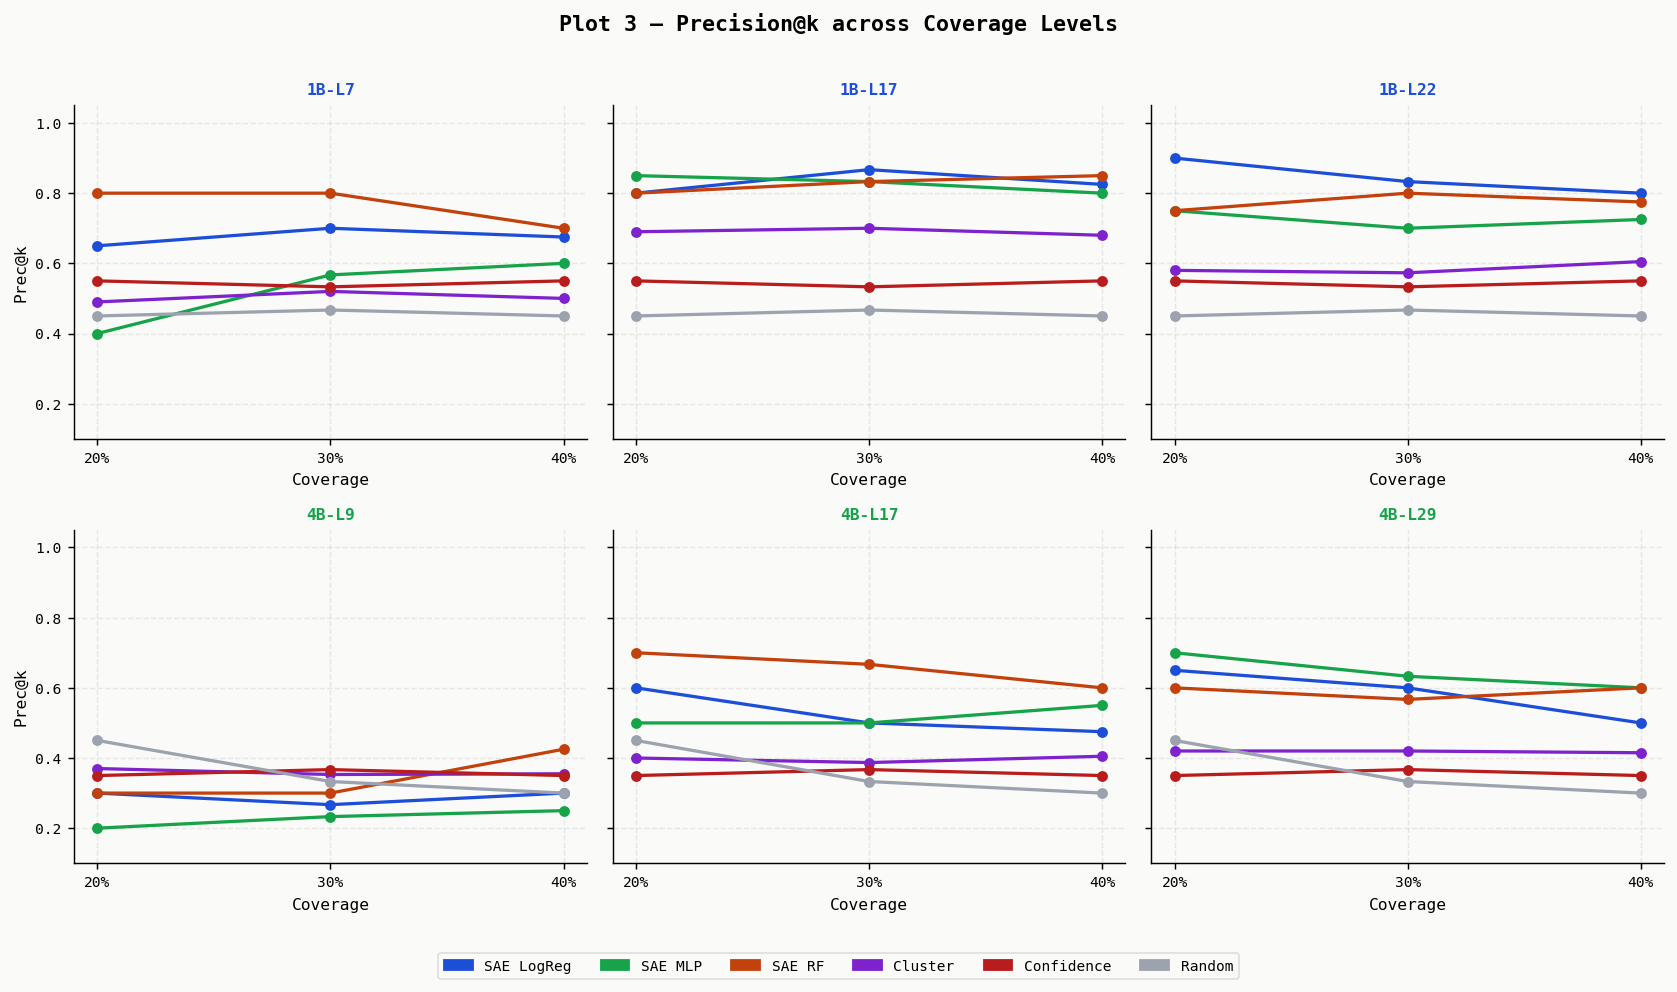

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
fig.suptitle('Plot 3 — Precision@k across Coverage Levels', fontweight='bold', y=1.01)

model_colors = ['#1d4ed8'] * 3 + ['#16a34a'] * 3  # title accent

for idx, (cfg, ax) in enumerate(zip(CONFIGS, axes.flat)):
    for sys, col in zip(SYSTEMS, COLORS):
        ax.plot(COVERAGES, PRECK[cfg][sys], marker='o', markersize=5,
                color=col, linewidth=1.8, label=sys)
    ax.set_title(cfg, fontsize=9, fontweight='bold', color=model_colors[idx])
    ax.set_xticks(COVERAGES)
    ax.set_xticklabels(['20%', '30%', '40%'])
    ax.set_ylim(0.10, 1.05)
    ax.set_xlabel('Coverage')
    if idx % 3 == 0:
        ax.set_ylabel('Prec@k')

handles = [mpatches.Patch(color=c, label=s) for s, c in zip(SYSTEMS, COLORS)]
fig.legend(handles=handles, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.9, edgecolor='#ddd')
plt.tight_layout()
plt.show()

## Plot 4 — Accuracy Remaining Line Charts

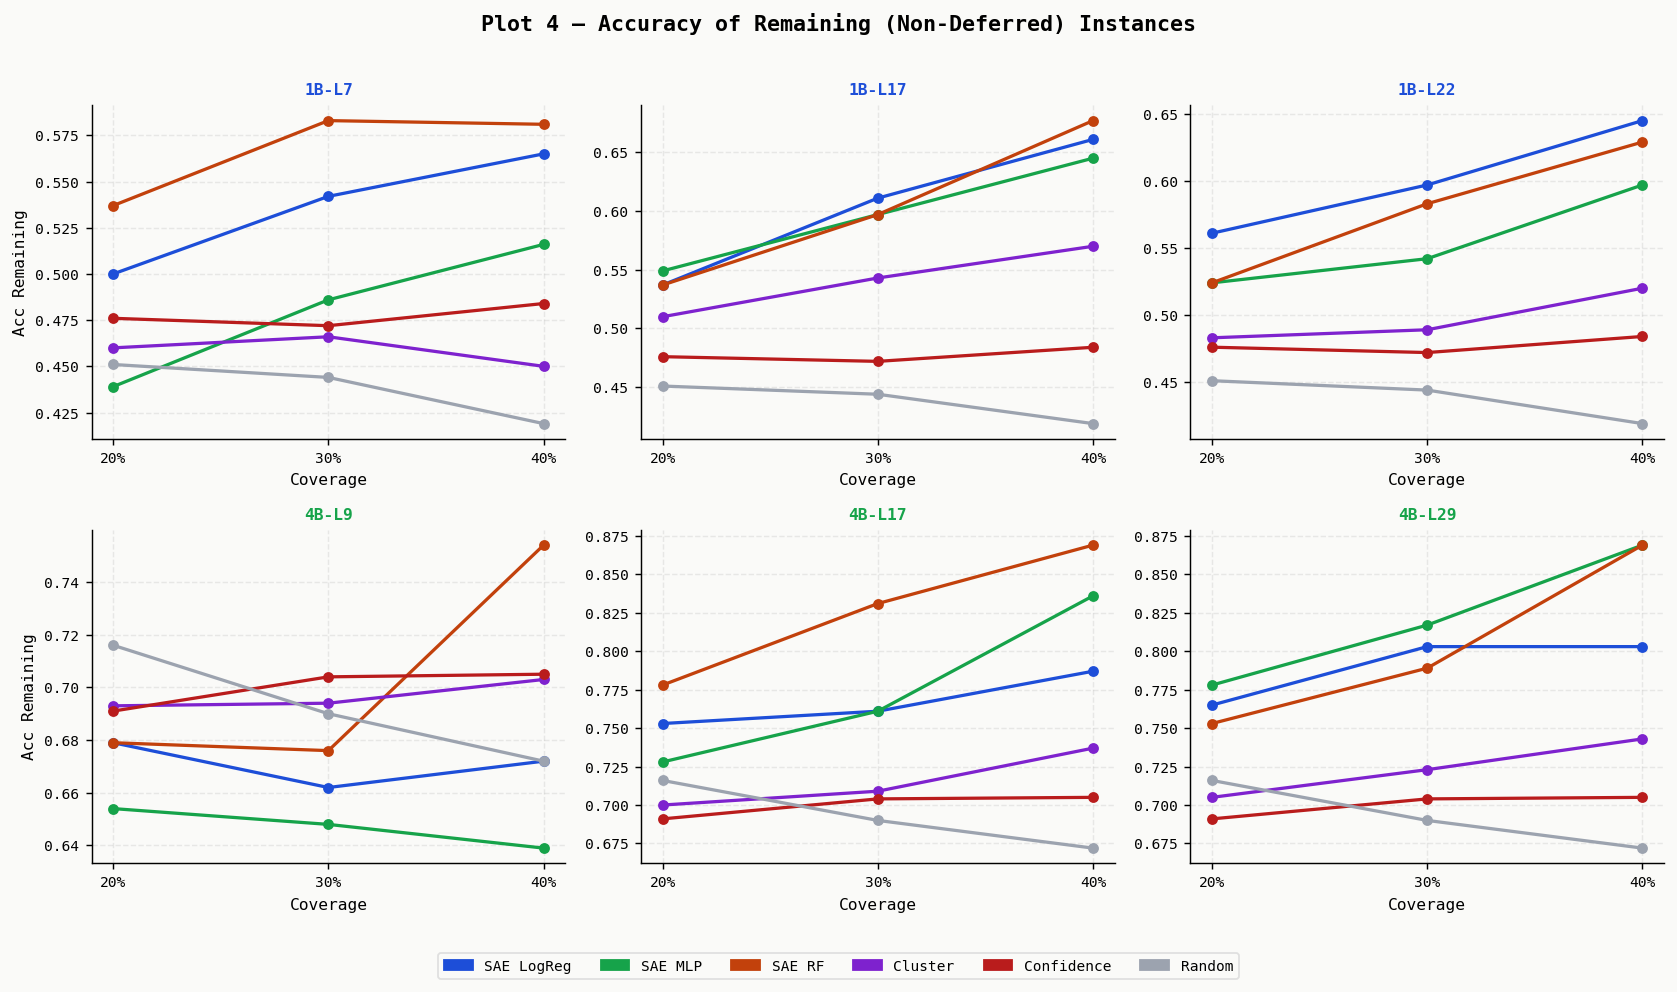

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
fig.suptitle('Plot 4 — Accuracy of Remaining (Non-Deferred) Instances', fontweight='bold', y=1.01)

for idx, (cfg, ax) in enumerate(zip(CONFIGS, axes.flat)):
    for sys, col in zip(SYSTEMS, COLORS):
        ax.plot(COVERAGES, ACCREM[cfg][sys], marker='o', markersize=5,
                color=col, linewidth=1.8, label=sys)
    ax.set_title(cfg, fontsize=9, fontweight='bold', color=model_colors[idx])
    ax.set_xticks(COVERAGES)
    ax.set_xticklabels(['20%', '30%', '40%'])
    ax.set_xlabel('Coverage')
    if idx % 3 == 0:
        ax.set_ylabel('Acc Remaining')

fig.legend(handles=handles, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.9, edgecolor='#ddd')
plt.tight_layout()
plt.show()

## Plot 5 — 1B Failure Cluster Profiles (Heatmap)

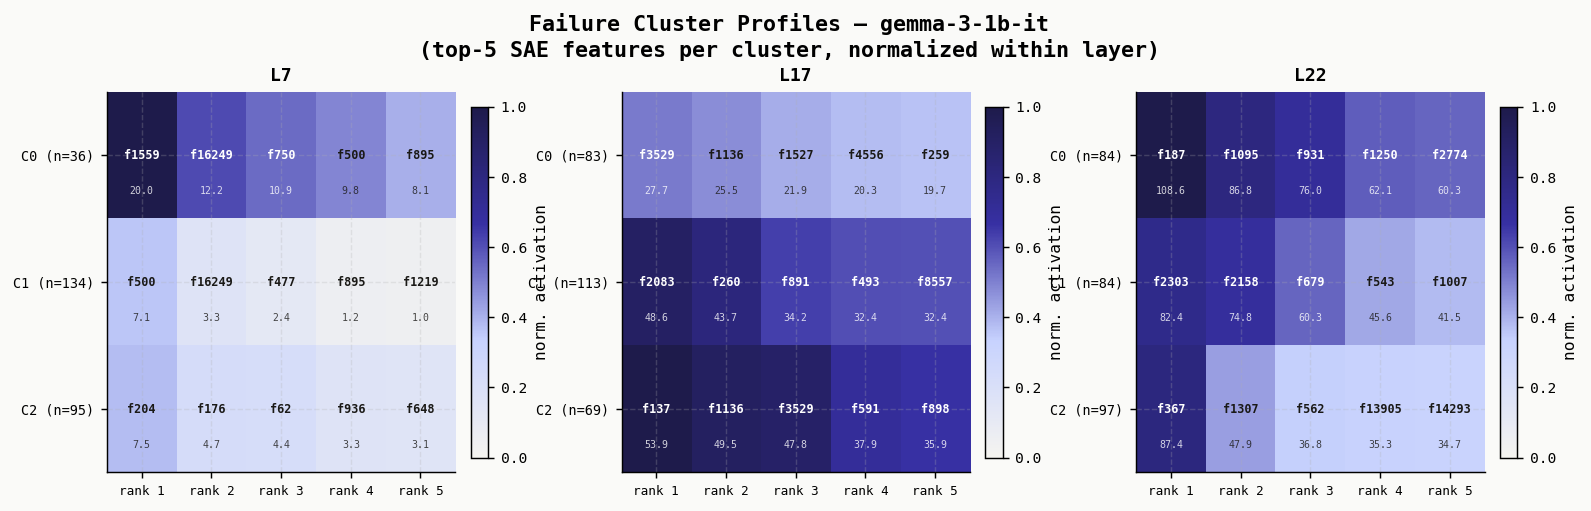

In [8]:
def draw_cluster_heatmap(hm_data, model_name, fig_ax=None):
    layers = list(hm_data.keys())
    n_layers = len(layers)   # 3
    n_clusters = 3
    n_feats = 5

    if fig_ax is None:
        fig, axes = plt.subplots(1, n_layers, figsize=(14, 3.8),
                                  gridspec_kw={'wspace': 0.35})
    else:
        fig, axes = fig_ax

    cmap = LinearSegmentedColormap.from_list(
        'cream_indigo', ['#f5f4f0', '#c7d2fe', '#3730a3', '#1e1b4b'])

    for li, (lyr, ax) in enumerate(zip(layers, axes)):
        clusters = hm_data[lyr]
        all_vals = [v for cl in clusters for _, v in cl['feats']]
        max_v = max(all_vals)

        mat = np.zeros((n_clusters, n_feats))
        feat_labels = []
        row_labels = [cl['label'] for cl in clusters]

        for ci, cl in enumerate(clusters):
            for fi, (fid, val) in enumerate(cl['feats']):
                mat[ci, fi] = val / max_v
                if ci == 0:
                    feat_labels.append(f'f{fid}')

        im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, aspect='auto')

        # Annotate cells with feature index + raw value
        for ci, cl in enumerate(clusters):
            for fi, (fid, val) in enumerate(cl['feats']):
                brightness = mat[ci, fi]
                tc = 'white' if brightness > 0.5 else '#1a1916'
                ax.text(fi, ci, f'f{fid}', ha='center', va='center',
                        fontsize=6.5, color=tc, fontweight='bold')
                ax.text(fi, ci + 0.28, f'{val:.1f}', ha='center', va='center',
                        fontsize=5.5, color=tc, alpha=0.8)

        ax.set_xticks(range(n_feats))
        ax.set_xticklabels([f'rank {i+1}' for i in range(n_feats)], fontsize=7)
        ax.set_yticks(range(n_clusters))
        ax.set_yticklabels(row_labels, fontsize=7.5)
        ax.set_title(f'{lyr}', fontsize=10, fontweight='bold', pad=6)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     label='norm. activation')

    if fig_ax is None:
        fig.suptitle(f'Failure Cluster Profiles — {model_name}\n'
                     '(top-5 SAE features per cluster, normalized within layer)',
                     fontweight='bold', y=1.04)
        plt.tight_layout()
        plt.show()

draw_cluster_heatmap(HM1B, 'gemma-3-1b-it')

## Plot 6 — 4B Failure Cluster Profiles (Heatmap)

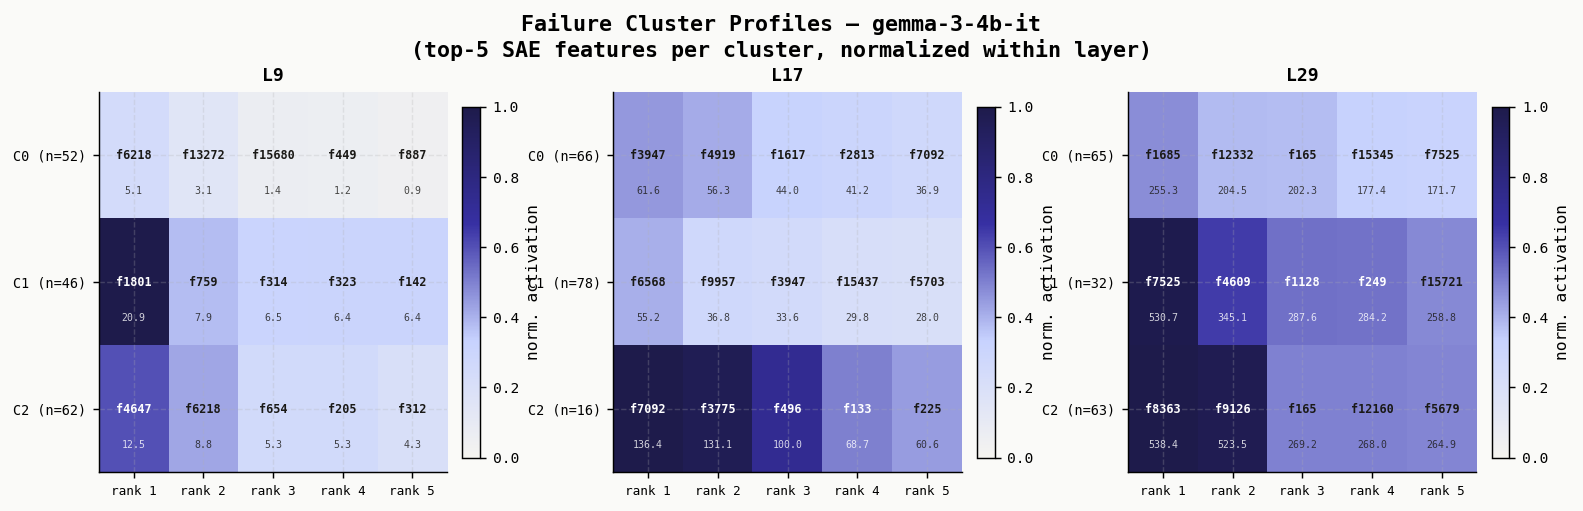

In [9]:
draw_cluster_heatmap(HM4B, 'gemma-3-4b-it')

## Plot 7 — UMAP Visualizations (Simulated Layout)
> **Note:** Positions are simulated from cluster centroids and error ratios. For exact embeddings, run `umap.UMAP().fit_transform(feature_matrix)` on the saved `feature_matrix.npy` files.

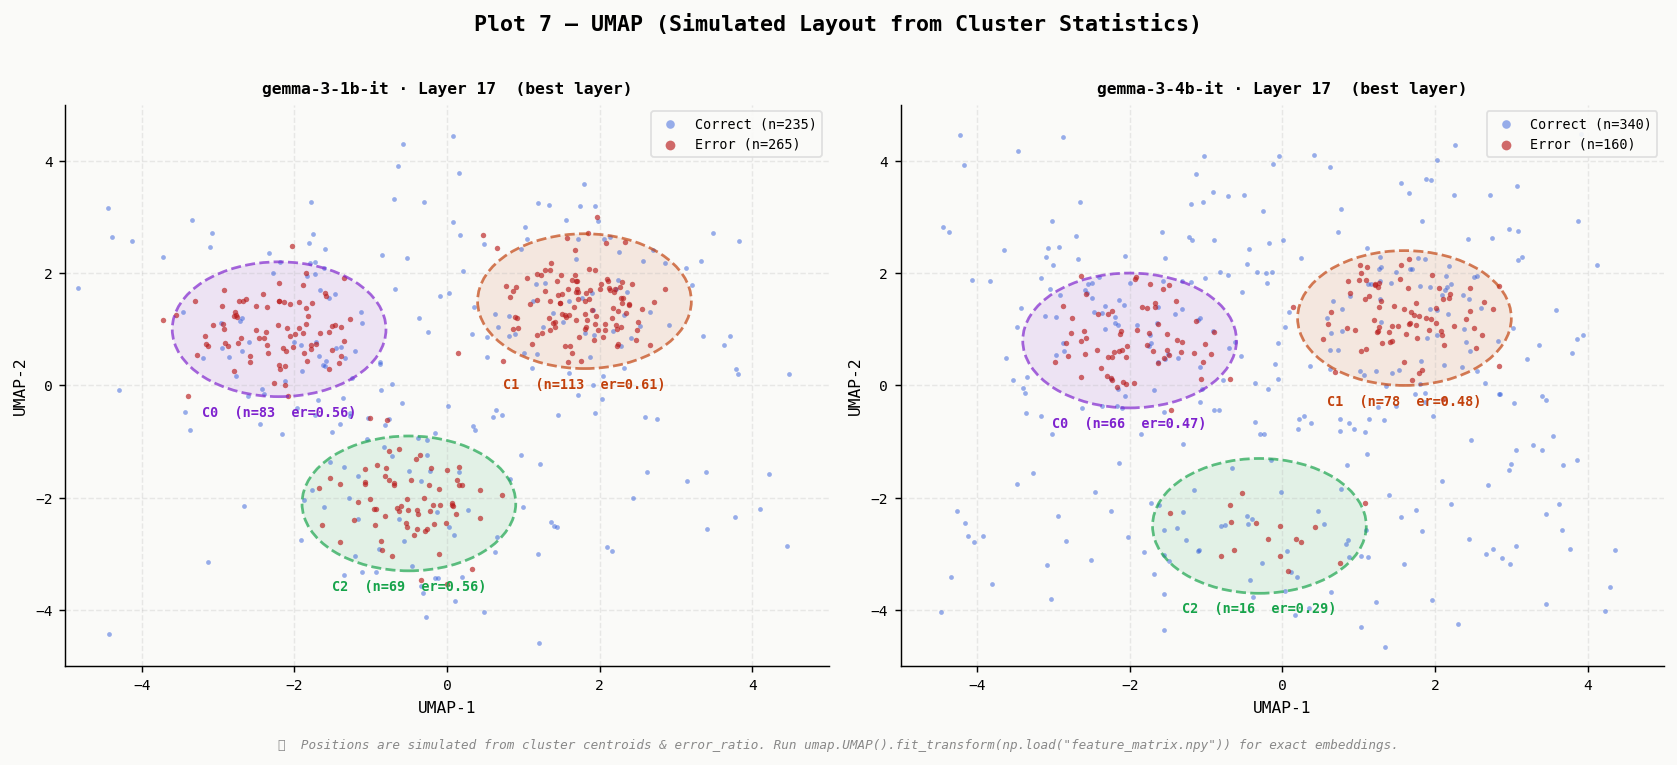

In [10]:
rng_state = np.random.RandomState(1337)

def simulate_umap(ax, cluster_cfg, total_correct, total_errors, title):
    """Simulate a UMAP scatter from cluster statistics."""
    pts_x, pts_y, pts_ok, pts_ci = [], [], [], []
    cluster_cols = ['#7e22ce', '#c2410c', '#16a34a']

    for ci, cl in enumerate(cluster_cfg):
        n_err = cl['n_errors']
        n_near_ok = int(n_err * (1 / cl['er'] - 1))
        # Error points — tight cluster
        ex = rng_state.normal(cl['cx'], 0.55, n_err)
        ey = rng_state.normal(cl['cy'], 0.55, n_err)
        pts_x.extend(ex); pts_y.extend(ey)
        pts_ok.extend([False]*n_err); pts_ci.extend([ci]*n_err)
        # Correct nearby — looser spread
        cx2 = rng_state.normal(cl['cx'], 1.1, n_near_ok)
        cy2 = rng_state.normal(cl['cy'], 1.1, n_near_ok)
        pts_x.extend(cx2); pts_y.extend(cy2)
        pts_ok.extend([True]*n_near_ok); pts_ci.extend([ci]*n_near_ok)

    # Background correct points
    used_ok = sum(pts_ok)
    rem = max(0, total_correct - used_ok)
    bx = rng_state.uniform(-4.5, 4.5, rem)
    by = rng_state.uniform(-4.5, 4.5, rem)
    pts_x.extend(bx); pts_y.extend(by)
    pts_ok.extend([True]*rem); pts_ci.extend([-1]*rem)

    pts_x = np.array(pts_x); pts_y = np.array(pts_y)
    pts_ok = np.array(pts_ok)

    # Shuffle
    perm = rng_state.permutation(len(pts_x))
    pts_x, pts_y, pts_ok = pts_x[perm], pts_y[perm], pts_ok[perm]

    # Draw background correct (blue)
    mask_ok = pts_ok
    ax.scatter(pts_x[mask_ok], pts_y[mask_ok], s=7, c='#1d4ed8',
               alpha=0.45, linewidths=0, label=f'Correct (n={total_correct})', zorder=2)
    # Draw errors (red)
    ax.scatter(pts_x[~mask_ok], pts_y[~mask_ok], s=9, c='#b91c1c',
               alpha=0.65, linewidths=0, label=f'Error (n={total_errors})', zorder=3)

    # Cluster boundary ellipses
    from matplotlib.patches import Ellipse
    for ci, cl in enumerate(cluster_cfg):
        el = Ellipse((cl['cx'], cl['cy']), width=2.8, height=2.4,
                     edgecolor=cluster_cols[ci], facecolor=cluster_cols[ci],
                     alpha=0.10, linewidth=1.5, linestyle='--', zorder=1)
        ax.add_patch(el)
        el2 = Ellipse((cl['cx'], cl['cy']), width=2.8, height=2.4,
                      edgecolor=cluster_cols[ci], facecolor='none',
                      alpha=0.65, linewidth=1.5, linestyle='--', zorder=4)
        ax.add_patch(el2)
        ax.text(cl['cx'], cl['cy'] - 1.55,
                f'C{ci}  (n={cl["n_errors"]}  er={cl["er"]:.2f})',
                ha='center', fontsize=7.5, color=cluster_cols[ci], fontweight='bold', zorder=5)

    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(loc='upper right', markerscale=1.8, fontsize=7.5,
              framealpha=0.9, edgecolor='#ddd')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Plot 7 — UMAP (Simulated Layout from Cluster Statistics)', fontweight='bold', y=1.01)

simulate_umap(ax1,
    [{'cx':-2.2,'cy':1.0,'n_errors':83, 'er':0.559},
     {'cx': 1.8,'cy':1.5,'n_errors':113,'er':0.607},
     {'cx':-0.5,'cy':-2.1,'n_errors':69,'er':0.564}],
    total_correct=235, total_errors=265,
    title='gemma-3-1b-it · Layer 17  (best layer)')

simulate_umap(ax2,
    [{'cx':-2.0,'cy':0.8, 'n_errors':66,'er':0.473},
     {'cx': 1.6,'cy':1.2, 'n_errors':78,'er':0.476},
     {'cx':-0.3,'cy':-2.5,'n_errors':16,'er':0.290}],
    total_correct=340, total_errors=160,
    title='gemma-3-4b-it · Layer 17  (best layer)')

fig.text(0.5, -0.02,
         '⚠  Positions are simulated from cluster centroids & error_ratio. '
         'Run umap.UMAP().fit_transform(np.load("feature_matrix.npy")) for exact embeddings.',
         ha='center', fontsize=7, color='#888', style='italic')

plt.tight_layout()
plt.show()

## Plot 8 — 1B vs 4B AUROC Comparison (averaged across layers)

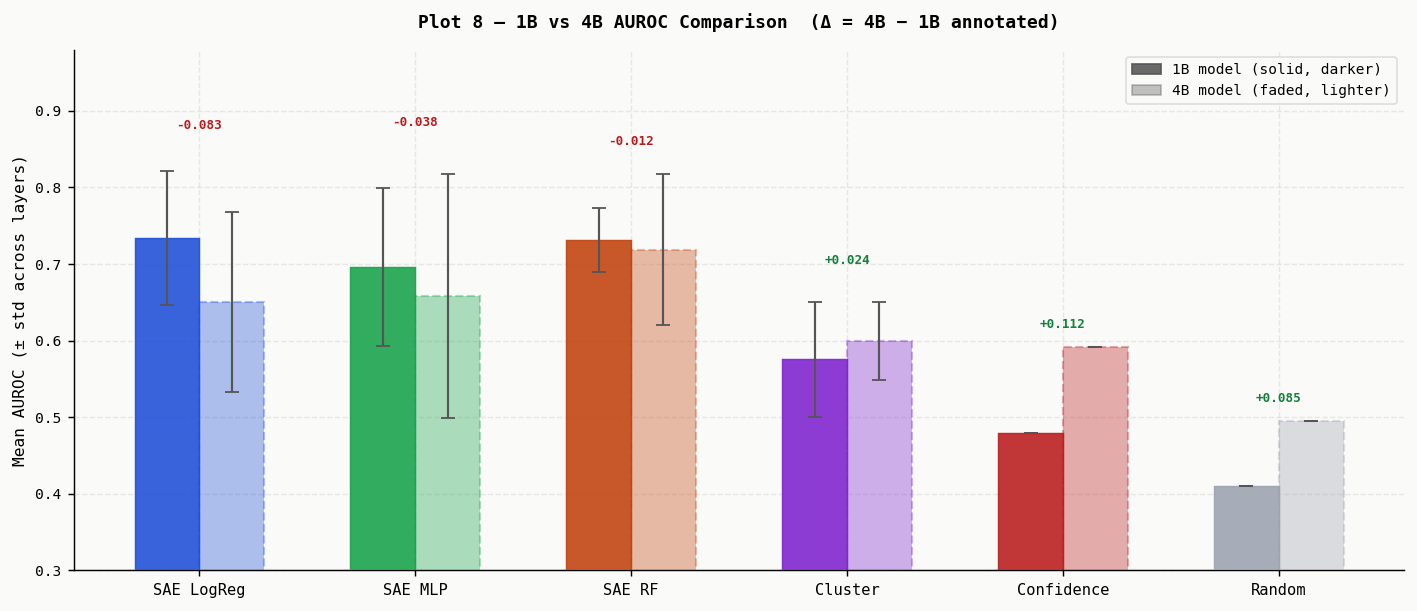

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.8))

auroc_1b = {s: np.array(AUROC[s][:3]) for s in SYSTEMS}
auroc_4b = {s: np.array(AUROC[s][3:]) for s in SYSTEMS}

mean_1b = [auroc_1b[s].mean() for s in SYSTEMS]
std_1b  = [auroc_1b[s].std()  for s in SYSTEMS]
mean_4b = [auroc_4b[s].mean() for s in SYSTEMS]
std_4b  = [auroc_4b[s].std()  for s in SYSTEMS]

xs = np.arange(len(SYSTEMS))
w = 0.30

bars1 = ax.bar(xs - w/2, mean_1b, width=w, yerr=std_1b,
               color=COLORS, alpha=0.88, capsize=4, ecolor='#555',
               error_kw={'linewidth':1.2}, label='1B (L7/17/22 avg)',
               edgecolor=COLORS, linewidth=0.8, zorder=3)

bars2 = ax.bar(xs + w/2, mean_4b, width=w, yerr=std_4b,
               color=COLORS, alpha=0.35, capsize=4, ecolor='#555',
               error_kw={'linewidth':1.2}, label='4B (L9/17/29 avg)',
               edgecolor=COLORS, linewidth=1.2, linestyle='--', zorder=3)

# Annotate delta (4B - 1B)
for i, (m1, m4) in enumerate(zip(mean_1b, mean_4b)):
    delta = m4 - m1
    col = '#15803d' if delta > 0 else '#b91c1c'
    ax.text(i, max(m1, m4) + max(std_1b[i], std_4b[i]) + 0.025,
            f'{delta:+.3f}', ha='center', fontsize=7, color=col, fontweight='bold')

ax.set_xticks(xs)
ax.set_xticklabels(SYSTEMS, fontsize=8.5)
ax.set_ylabel('Mean AUROC (± std across layers)')
ax.set_ylim(0.30, 0.98)
ax.set_title('Plot 8 — 1B vs 4B AUROC Comparison  (Δ = 4B − 1B annotated)',
             fontweight='bold', pad=12)

# Custom legend
leg_patches = [
    mpatches.Patch(color='#555', alpha=0.88, label='1B model (solid, darker)'),
    mpatches.Patch(color='#555', alpha=0.35, label='4B model (faded, lighter)'),
]
ax.legend(handles=leg_patches, loc='upper right', framealpha=0.9, edgecolor='#ddd')

plt.tight_layout()
plt.show()